# Does the `hate` contribution "seem to self" across layers?

Prompt (already cached): **`I hate this person. I think he is so`**, model `meta-llama/Llama-3.1-8B`.

We take the residual-stream contribution at the **last position** (`so`) that is **sourced from the `hate` token**, one vector per layer, and compute the **cosine similarity between consecutive layers**. If the direction is stable across depth, consecutive cosines stay close to 1 ("seems to self").

We reuse `ModelInformationCalculatorF32.consecutive_cosine_similarities` and the cached `FullRunResults` (no remote run needed).

In [1]:
import sys
from pathlib import Path

import torch

# Make the backend package importable (api_checks, info_flow live under real/backend/src).
BACKEND_SRC = Path.cwd().parents[0] / "real" / "backend" / "src"
if not BACKEND_SRC.exists():
    # fallback if the notebook is run from a different cwd
    BACKEND_SRC = Path(
        r"c:\Users\wildn\Desktop\New life\AI\Expirments\VisulaiztionInfoFlowDemo\real\backend\src"
    )
assert BACKEND_SRC.exists(), BACKEND_SRC
sys.path.insert(0, str(BACKEND_SRC))

from api_checks.api_cache import APICache  # noqa: E402
from api_checks.position import LLMResidualPosition  # noqa: E402
from info_flow.config import Config  # noqa: E402

PROMPT = "I hate this person. I think he is so"
config = Config()
MODEL = config.info_flow_model
api_cache = APICache(hf_token=config.hf_token, cache_path=Path(config.result_cache_path))
print("model:", MODEL)

c:\Users\wildn\Desktop\New life\AI\Expirments\VisulaiztionInfoFlowDemo\real\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model: meta-llama/Llama-3.1-8B


In [2]:
%load_ext autoreload
%autoreload 1
%aimport api_checks.model_calculator
%aimport api_checks.api_cache

In [3]:
# Cached run -> CACHE HIT (no remote). Calculator gives us tokens + the cosine helper.
calculator = api_cache.get_infomration_calculator(MODEL)
run = api_cache.get_full_run_results(MODEL, PROMPT)

tokens = calculator.calc_tokens(PROMPT)  # list[str], one per source position
LAST_POS = run.dimentions.prompt_len - 1
N_LAYERS = run.dimentions.layers

# Find the source position of the `hate` token (single token here, but match programmatically).
hate_sources = [i for i, t in enumerate(tokens) if "hate" in t.lower()]
assert len(hate_sources) == 1, f"expected exactly one 'hate' token, got {hate_sources}"
HATE_SOURCE = hate_sources[0]

print("tokens:", list(enumerate(tokens)))
print(f"hate source idx = {HATE_SOURCE} ({tokens[HATE_SOURCE]!r}), "
      f"last pos = {LAST_POS} ({tokens[LAST_POS]!r}), layers = {N_LAYERS}")

CACHE HIT meta-llama/Llama-3.1-8B I hate this person. I think he is so 2026-06-15 09:23:29.635364
tokens: [(0, '<|begin_of_text|>'), (1, 'I'), (2, ' hate'), (3, ' this'), (4, ' person'), (5, '.'), (6, ' I'), (7, ' think'), (8, ' he'), (9, ' is'), (10, ' so')]
hate source idx = 2 (' hate'), last pos = 10 (' so'), layers = 32


In [4]:
# One vector per layer: the post-MLP residual-stream contribution at the LAST position
# coming from the `hate` source token.  contributions[pos][source] -> (d_model,)
# (is_mlp=True = full residual stream after each block; flip to False for post-attention only.)
hate_vectors_per_layer = [
    run.contributions[
        LLMResidualPosition(layer=l, token_position=LAST_POS, is_mlp=True)
    ][HATE_SOURCE].float()
    for l in range(N_LAYERS)
]
assert len(hate_vectors_per_layer) == N_LAYERS
assert hate_vectors_per_layer[0].shape == (run.dimentions.d_model,)

# Consecutive cosine similarities across layers (reused from the calculator). len = N_LAYERS - 1.
consecutive_cos = calculator.consecutive_cosine_similarities(hate_vectors_per_layer)
assert len(consecutive_cos) == N_LAYERS - 1

for l, c in enumerate(consecutive_cos):
    print(f"L{l:>2} -> L{l + 1:<2}: {c:+.3f}")

L 0 -> L1 : +0.550
L 1 -> L2 : +0.636
L 2 -> L3 : +0.593
L 3 -> L4 : +0.667
L 4 -> L5 : +0.704
L 5 -> L6 : +0.744
L 6 -> L7 : +0.728
L 7 -> L8 : +0.804
L 8 -> L9 : +0.814
L 9 -> L10: +0.831
L10 -> L11: +0.856
L11 -> L12: +0.815
L12 -> L13: +0.791
L13 -> L14: +0.827
L14 -> L15: +0.864
L15 -> L16: +0.889
L16 -> L17: +0.891
L17 -> L18: +0.920
L18 -> L19: +0.933
L19 -> L20: +0.938
L20 -> L21: +0.940
L21 -> L22: +0.952
L22 -> L23: +0.948
L23 -> L24: +0.954
L24 -> L25: +0.953
L25 -> L26: +0.972
L26 -> L27: +0.968
L27 -> L28: +0.966
L28 -> L29: +0.959
L29 -> L30: +0.902
L30 -> L31: +0.606


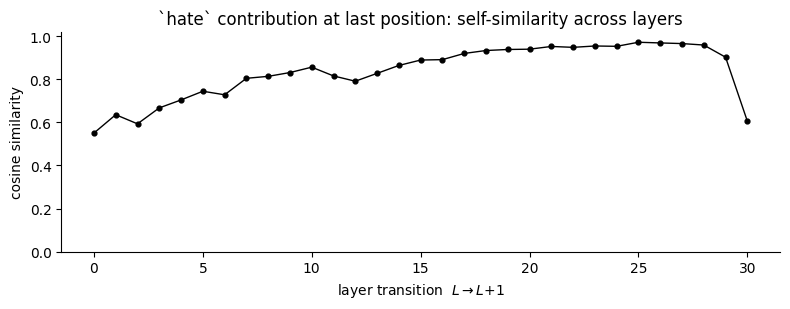

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.2))
x = range(N_LAYERS - 1)
ax.plot(x, consecutive_cos, color="black", linewidth=1)
ax.scatter(x, consecutive_cos, color="black", s=12)
ax.set_xlabel("layer transition  $L \\rightarrow L{+}1$")
ax.set_ylabel("cosine similarity")
ax.set_title(f"`{tokens[HATE_SOURCE].strip()}` contribution at last position: self-similarity across layers")
ax.set_ylim(0, 1.02)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## Better view: full pairwise similarity + baselines

Consecutive cosines are high, but that only compares each layer to its neighbour. To see whether the direction is *globally* stable we need every layer-pair — e.g. **L2 vs L10**. The heatmap below does that.

As **baselines** (how self-similar are residual directions *in general*?) we add the *full* residual-stream vector (sum of all sources, from `run.precise`) at:
- **(a)** the **last** position (`so`), and
- **(b)** the **first** content position (`I`, index 1, just after `<|begin_of_text|>`).

In [6]:
import torch.nn.functional as F

FIRST_POS = 1  # one after <|begin_of_text|>

# Baseline vectors: the FULL residual stream (all sources summed), from run.precise.
full_last_per_layer = [
    run.precise[LLMResidualPosition(layer=l, token_position=LAST_POS, is_mlp=True)].float()
    for l in range(N_LAYERS)
]
full_first_per_layer = [
    run.precise[LLMResidualPosition(layer=l, token_position=FIRST_POS, is_mlp=True)].float()
    for l in range(N_LAYERS)
]


def pairwise_cosine_matrix(vectors: list[torch.Tensor]) -> torch.Tensor:
    """(L, L) cosine-similarity matrix between every pair of layer vectors. CLAUDE_WRITTEN"""
    M = F.normalize(torch.stack(vectors), dim=1)  # (L, d), unit rows
    return M @ M.T  # (L, L)


cos_matrix = pairwise_cosine_matrix(hate_vectors_per_layer)  # (L, L)
assert torch.allclose(cos_matrix.diagonal(), torch.ones(N_LAYERS), atol=1e-5)
print(f"L{2} vs L{10} similarity = {cos_matrix[2, 10]:.3f}  (consecutive L2->L3 was {consecutive_cos[2]:.3f})")

L2 vs L10 similarity = 0.147  (consecutive L2->L3 was 0.593)


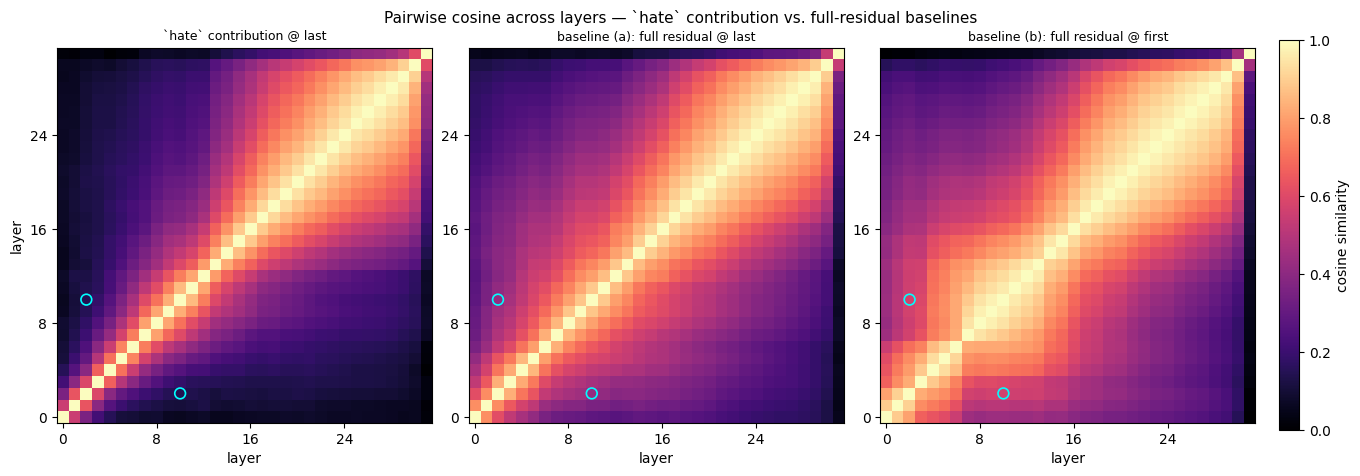

In [7]:
# Full pairwise cosine heatmaps, side by side: the `hate` contribution and the two
# full-residual baselines. Same colour scale so the matrices are directly comparable.
# Off-diagonal falloff = long-range drift the consecutive view hides (e.g. L2 vs L10).
panels = [
    (pairwise_cosine_matrix(hate_vectors_per_layer), f"`{tokens[HATE_SOURCE].strip()}` contribution @ last"),
    (pairwise_cosine_matrix(full_last_per_layer), "baseline (a): full residual @ last"),
    (pairwise_cosine_matrix(full_first_per_layer), "baseline (b): full residual @ first"),
]
ticks = range(0, N_LAYERS, 8)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), constrained_layout=True)
for ax, (mat, title) in zip(axes, panels):
    im = ax.imshow(mat.numpy(), origin="lower", cmap="magma", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("layer")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    # Mark the L2 vs L10 cell on every panel for easy comparison.
    ax.scatter([10, 2], [2, 10], facecolors="none", edgecolors="cyan", s=60, linewidths=1.2)
axes[0].set_ylabel("layer")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="cosine similarity")
fig.suptitle("Pairwise cosine across layers — `hate` contribution vs. full-residual baselines", fontsize=11)
plt.show()

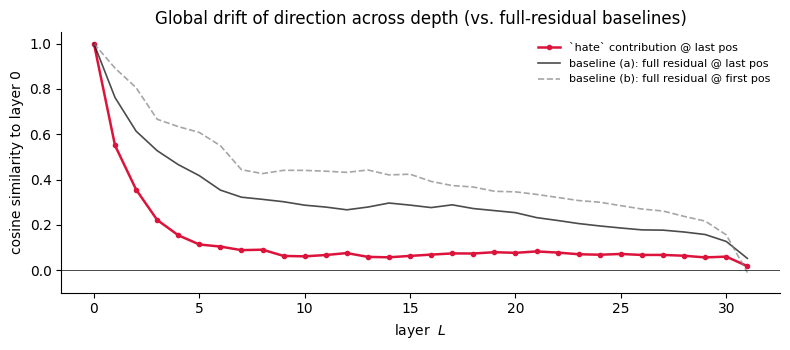

In [8]:
# Drift-from-origin curve: cosine of every layer to layer 0 (= row 0 of each pairwise matrix),
# with the two full-residual baselines overlaid. Shows global drift, not just neighbour-to-neighbour.
drift_hate = pairwise_cosine_matrix(hate_vectors_per_layer)[0]
drift_last = pairwise_cosine_matrix(full_last_per_layer)[0]    # baseline (a)
drift_first = pairwise_cosine_matrix(full_first_per_layer)[0]  # baseline (b)

fig, ax = plt.subplots(figsize=(8, 3.6))
x = range(N_LAYERS)
ax.plot(x, drift_hate, color="crimson", linewidth=1.8, marker="o", ms=3, label="`hate` contribution @ last pos")
ax.plot(x, drift_last, color="black", linewidth=1.2, alpha=0.7, label="baseline (a): full residual @ last pos")
ax.plot(x, drift_first, color="gray", linewidth=1.2, alpha=0.7, ls="--", label="baseline (b): full residual @ first pos")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("layer  $L$")
ax.set_ylabel("cosine similarity to layer 0")
ax.set_title("Global drift of direction across depth (vs. full-residual baselines)")
ax.set_ylim(-0.1, 1.05)
ax.legend(frameon=False, fontsize=8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## Each source vs. the start-of-context source, per layer

At the **last position**, the residual stream decomposes into one contribution per source token. Here we compare **every** source's contribution to the **start-of-context** source (`<|begin_of_text|>`, index 0) — cosine similarity, one value per (layer, source). Rows = layers, columns = source token. The first column is the reference, so it is 1 by construction.

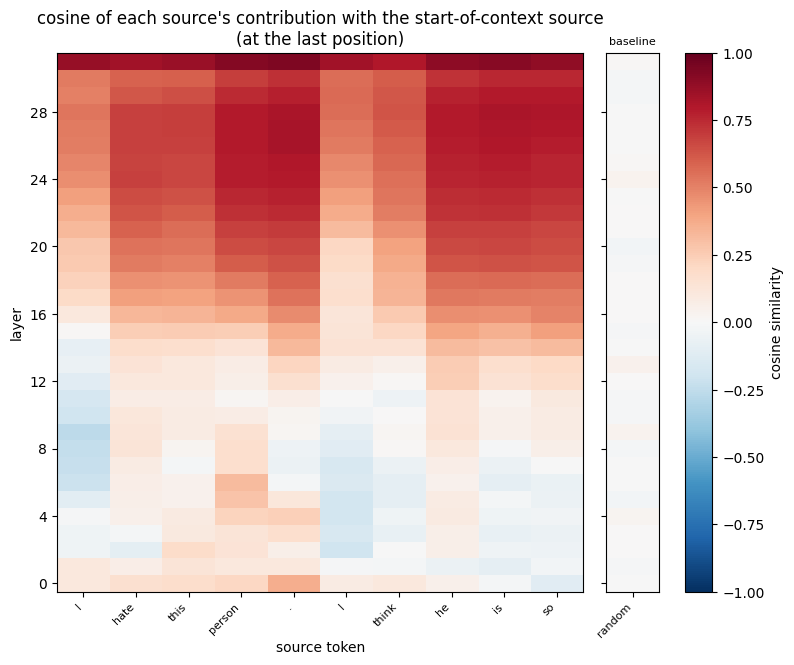

In [9]:
REF_SOURCE = 0  # <|begin_of_text|> = start-of-context

# Per-source contributions at the last position, one (source, d_model) slab per layer.
C = torch.stack([
    run.contributions[LLMResidualPosition(layer=l, token_position=LAST_POS, is_mlp=True)].float()
    for l in range(N_LAYERS)
])  # (L, S, d)
Cn = F.normalize(C, dim=-1)
ref = Cn[:, REF_SOURCE, :]                       # (L, d)  the BOS contribution per layer
source_vs_bos = torch.einsum("lsd,ld->ls", Cn, ref)  # (L, S) cosine of each source with BOS
assert torch.allclose(source_vs_bos[:, REF_SOURCE], torch.ones(N_LAYERS), atol=1e-4)
assert not torch.isnan(source_vs_bos).any()

# Drop the BOS column (trivially 1) -> keep real sources only.
M = source_vs_bos[:, REF_SOURCE + 1:]            # (L, S-1)
col_labels = [t.strip() for t in tokens[REF_SOURCE + 1:]]

# Baseline strip: a fresh random unit vector per layer (re-randomised every run),
# cosine with the BOS contribution. Expected ~0 (std ~ 1/sqrt(d_model)) = "no alignment".
rand = F.normalize(torch.randn(N_LAYERS, run.dimentions.d_model), dim=-1)  # (L, d)
random_vs_bos = (rand * ref).sum(dim=-1, keepdim=True)                     # (L, 1)

# origin="lower" -> layer 0 at the bottom, increasing upward (small -> big).
fig, (ax, ax_r) = plt.subplots(
    1, 2, figsize=(8.5, 7), sharey=True, gridspec_kw={"width_ratios": [M.shape[1], 1], "wspace": 0.08}
)
im = ax.imshow(M.numpy(), origin="lower", cmap="RdBu_r", vmin=-1.0, vmax=1.0, aspect="auto")
ax.set_xlabel("source token")
ax.set_ylabel("layer")
ax.set_title("cosine of each source's contribution with the start-of-context source\n(at the last position)")
ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(0, N_LAYERS, 4))

ax_r.imshow(random_vs_bos.numpy(), origin="lower", cmap="RdBu_r", vmin=-1.0, vmax=1.0, aspect="auto")
ax_r.set_xticks([0])
ax_r.set_xticklabels(["random"], rotation=45, ha="right", fontsize=8)
ax_r.set_title("baseline", fontsize=8)

fig.colorbar(im, ax=[ax, ax_r], fraction=0.046, pad=0.04, label="cosine similarity")
plt.show()

In [13]:
import sys
from pathlib import Path

import torch

# Make the backend package importable (api_checks, info_flow live under real/backend/src).
BACKEND_SRC = Path.cwd().parents[0] / "real" / "backend" / "src"
if not BACKEND_SRC.exists():
    # fallback if the notebook is run from a different cwd
    BACKEND_SRC = Path(
        r"c:\Users\wildn\Desktop\New life\AI\Expirments\VisulaiztionInfoFlowDemo\real\backend\src"
    )
assert BACKEND_SRC.exists(), BACKEND_SRC
sys.path.insert(0, str(BACKEND_SRC))

from api_checks.api_cache import APICache  # noqa: E402
from api_checks.position import LLMResidualPosition  # noqa: E402
from info_flow.config import Config  # noqa: E402

PROMPT = "I hate this person. I think he is so"
config = Config()
MODEL = config.info_flow_model
api_cache = APICache(hf_token=config.hf_token, cache_path=Path(config.result_cache_path))
print("model:", MODEL)
calculator = api_cache.get_infomration_calculator(MODEL)
run = api_cache.get_full_run_results(MODEL, PROMPT)

tokens = calculator.calc_tokens(PROMPT)  # list[str], one per source position
LAST_POS = run.dimentions.prompt_len - 1
N_LAYERS = run.dimentions.layers

# Find the source position of the `hate` token (single token here, but match programmatically).
hate_sources = [i for i, t in enumerate(tokens) if "hate" in t.lower()]
assert len(hate_sources) == 1, f"expected exactly one 'hate' token, got {hate_sources}"
HATE_SOURCE = hate_sources[0]

print("tokens:", list(enumerate(tokens)))
print(f"hate source idx = {HATE_SOURCE} ({tokens[HATE_SOURCE]!r}), "
      f"last pos = {LAST_POS} ({tokens[LAST_POS]!r}), layers = {N_LAYERS}")

model: meta-llama/Llama-3.1-8B
CACHE HIT meta-llama/Llama-3.1-8B I hate this person. I think he is so 2026-06-15 09:23:29.635364
tokens: [(0, '<|begin_of_text|>'), (1, 'I'), (2, ' hate'), (3, ' this'), (4, ' person'), (5, '.'), (6, ' I'), (7, ' think'), (8, ' he'), (9, ' is'), (10, ' so')]
hate source idx = 2 (' hate'), last pos = 10 (' so'), layers = 32


In [18]:
information = api_cache.get_full_run_results(MODEL, PROMPT)

last_residual_vector = information.contributions[LLMResidualPosition(layer=N_LAYERS-1,token_position=LAST_POS,is_mlp=True)].sum(dim=0)
unembedding_matrix = api_cache.get_unembedding_matrix(MODEL)
print("Got unembedding")
print(calculator.calc_top_perdictions_from_vector(last_residual_vector,unembedding_matrix,rms_weight=api_cache.get_last_rms_weight(MODEL)))


Got unembedding
OrderedDict({' stupid': 0.07165058702230453, ' full': 0.06493432819843292, ' annoying': 0.05206843465566635, ' rude': 0.045587293803691864, ' arrogant': 0.03528573736548424})


In [ ]:
information = api_cache.get_full_run_results(MODEL, PROMPT)

last_residual_vector_start_contribitopon = information.contributions[LLMResidualPosition(layer=N_LAYERS-1,token_position=LAST_POS,is_mlp=True)][0]
unembedding_matrix = api_cache.get_unembedding_matrix(MODEL)
print("Got unembedding")
print(calculator.calc_top_perdictions_from_vector(last_residual_vector_start_contribitopon,unembedding_matrix,rms_weight=api_cache.get_last_rms_weight(MODEL)))


Got unembedding
OrderedDict({' annoying': 0.05533692240715027, ' rude': 0.04064862057566643, ' full': 0.031849075108766556, ' stupid': 0.0267118401825428, ' mean': 0.022898869588971138})


In [19]:
print(calculator.calc_top_perdictions_from_vector(last_residual_vector-last_residual_vector_start_contribitopon,unembedding_matrix,rms_weight=api_cache.get_last_rms_weight(MODEL)))


OrderedDict({' stupid': 0.13274222612380981, ' full': 0.09462542831897736, ' arrogant': 0.04510335251688957, ' rude': 0.039534326642751694, ' annoying': 0.03850587084889412})


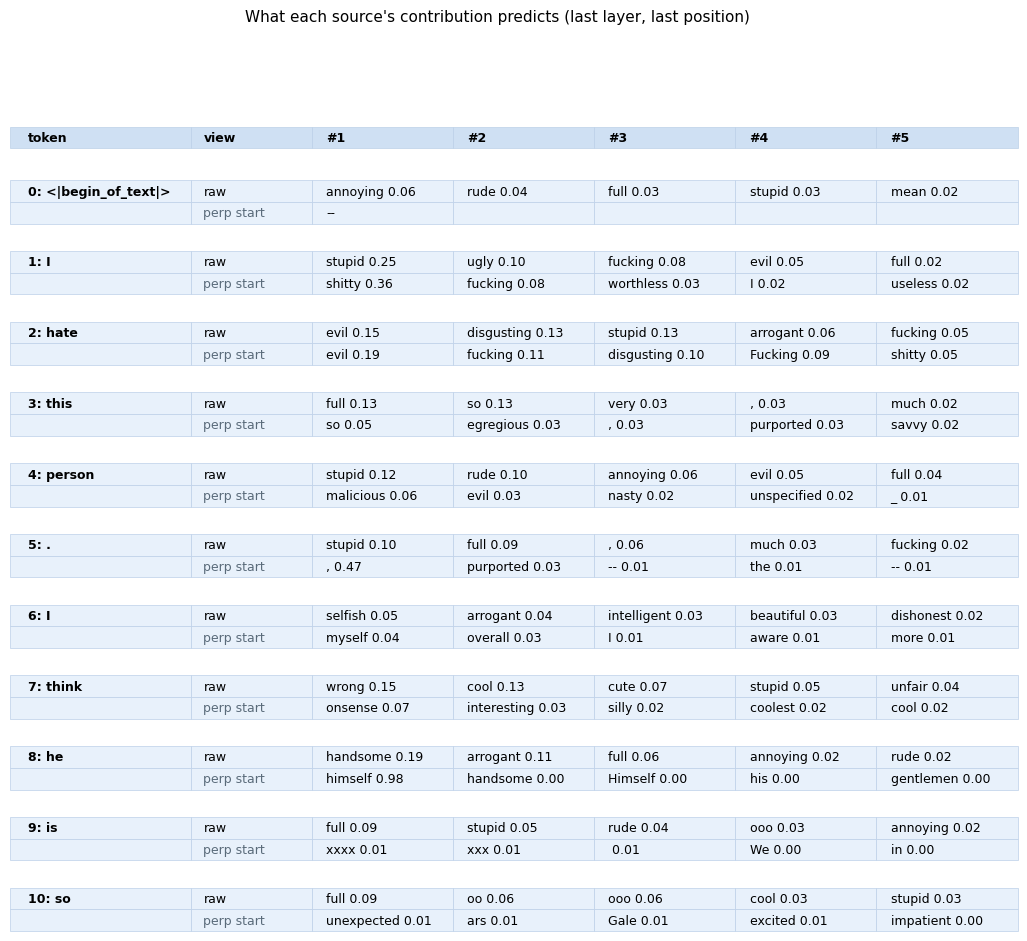

In [48]:
# Per-source contributions at the last layer/last position: what does each source
# token's contribution alone predict? Source 0 is the start-of-context (BOS) vector.
# Instead of plain c[i] - c[0], we remove only the COMPONENT of c[i] along c[0]
# (vector rejection): c[i] - (c[i].c[0] / ||c[0]||^2) c[0]. This strips the shared
# start-of-context direction while leaving c[i]'s magnitude in every orthogonal direction.
contributions = information.contributions[
    LLMResidualPosition(layer=N_LAYERS - 1, token_position=LAST_POS, is_mlp=True)
]  # (S, d_model)
rms_weight = api_cache.get_last_rms_weight(MODEL)


def top_preds(vec):
    return calculator.calc_top_perdictions_from_vector(vec, unembedding_matrix, rms_weight=rms_weight)


def fmt(preds):
    return ", ".join(f"{tok!r} {p:.3f}" for tok, p in preds.items())


def remove_proj(v, onto):
    """Remove the component of v along `onto` (vector rejection). CLAUDE_WRITTEN"""
    return v - (torch.dot(v, onto) / torch.dot(onto, onto)) * onto


def predictions_table(tokens, raw_per_source, minus_per_source, title, topk=5):
    """One small light-blue table per source token (raw / start-direction-removed rows),
    the tables spaced apart so each word reads as its own block. CLAUDE_WRITTEN"""
    def cells(preds):  # top-k as 'tok p' strings, padded to length topk
        items = [f"{t.strip()} {p:.2f}" for t, p in list(preds.items())[:topk]]
        return items + [""] * (topk - len(items))

    col_labels = ["token", "view"] + [f"#{r + 1}" for r in range(topk)]
    col_widths = [0.18, 0.12] + [0.70 / topk] * topk
    n = len(tokens)

    fig = plt.figure(figsize=(13, 0.85 * n + 1.0))
    gs = fig.add_gridspec(n + 1, 1, height_ratios=[0.6] + [1] * n, hspace=1.3)

    def style(tbl, facecolor):
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1, 1.3)
        for cell in tbl.get_celld().values():
            cell.set_edgecolor("#bcd0e8")
            cell.set_linewidth(0.5)
            cell.set_facecolor(facecolor)

    # Header strip (drawn once), slightly darker blue.
    hax = fig.add_subplot(gs[0]); hax.axis("off")
    htab = hax.table(cellText=[col_labels], colWidths=col_widths, cellLoc="left", loc="center")
    style(htab, "#cfe0f3")
    for cell in htab.get_celld().values():
        cell.set_text_props(fontweight="bold")

    # One light-blue table per token, well separated by the figure background.
    for i, tok in enumerate(tokens):
        ax = fig.add_subplot(gs[i + 1]); ax.axis("off")
        perp = cells(minus_per_source[i]) if i in minus_per_source else ["--"] + [""] * (topk - 1)
        rows = [[f"{i}: {tok.strip()}", "raw", *cells(raw_per_source[i])],
                ["", "perp start", *perp]]
        tbl = ax.table(cellText=rows, colWidths=col_widths, cellLoc="left", loc="center")
        style(tbl, "#e8f1fb")
        tbl[(0, 0)].set_text_props(fontweight="bold")   # token name
        tbl[(1, 1)].get_text().set_color("#5a6b7a")     # muted "perp start" label

    fig.suptitle(title, fontsize=11, y=0.995)
    plt.show()


raw_per_source = [top_preds(contributions[i]) for i in range(len(tokens))]
# Projecting out the start direction only makes sense for non-start sources (i >= 1).
minus_sources = range(1, len(tokens))
minus_per_source = {i: top_preds(remove_proj(contributions[i], contributions[0])) for i in minus_sources}

predictions_table(tokens, raw_per_source, minus_per_source,
                  "What each source's contribution predicts (last layer, last position)")


In [23]:
# Glossary for the "weird" tokens that dominate the start-removed predictions.
# These are under-trained / glitch tokens: rare web-scrape fragments (German/Swedish
# dating-site & adult spam, a Danish city) the model barely learned, so a near-random
# residual direction projects onto them.
DEFINITIONS = {
    "weiber": "German, colloquial/pejorative plural of 'Weib' = women.",
    "geschichten": "German = 'stories' / 'histories'.",
    "dejtingsajt": "Swedish = 'dating site' (dejtingsaj-/dejtings- are BPE fragments of it).",
    "dejtingsaj": "Swedish fragment of 'dejtingsajt' = dating site.",
    "dejtings": "Swedish fragment of 'dejtingsajt' = dating site.",
    "swingerclub": "German/English = swingers' club.",
    "analsex": "German/English = anal sex.",
    "aalborg": "Aalborg = a city in Denmark.",
}

# Collect every distinct token shown in the start-removed predictions.
weird_tokens = {tok.strip() for preds in minus_per_source.values() for tok in preds}

print("definitions of the start-removed (glitch) tokens:\n")
for tok in sorted(weird_tokens):
    print(f"  {tok!r:>16}: {DEFINITIONS.get(tok.lower(), '??? (unknown / under-trained token)')}")

definitions of the start-removed (glitch) tokens:

         'aalborg': Aalborg = a city in Denmark.
         'analsex': German/English = anal sex.
        'dejtings': Swedish fragment of 'dejtingsajt' = dating site.
      'dejtingsaj': Swedish fragment of 'dejtingsajt' = dating site.
     'geschichten': German = 'stories' / 'histories'.
     'swingerclub': German/English = swingers' club.
          'weiber': German, colloquial/pejorative plural of 'Weib' = women.


In [24]:
# Decisive test: what does a PURE RANDOM direction unembed to?
# If random vectors also spit out weiber/dejtingsajt/..., then those tokens are a
# property of the unembedding (under-trained "glitch" tokens), NOT a dating-site signal
# tied to our prompt. RMSNorm makes scale irrelevant, so unit-norm Gaussians are fine.
d_model = contributions.shape[1]
for seed in range(5):
    g = torch.Generator().manual_seed(seed)
    rand_vec = torch.randn(d_model, generator=g)
    print(f"random seed {seed}: {fmt(top_preds(rand_vec))}")

random seed 0: 'anza' 0.038, 'onne' 0.009, 'ance' 0.008, 'ino' 0.007, 'atar' 0.007
random seed 1: 'emens' 0.015, 'OldData' 0.014, 'jay' 0.009, 'ToDevice' 0.006, ' Hatch' 0.004
random seed 2: '�' 0.045, 'ucha' 0.029, 'ATUS' 0.010, ' Mile' 0.009, 'まり' 0.007
random seed 3: '297' 0.036, 'osaur' 0.018, 'aser' 0.012, 'urf' 0.012, 'osaurs' 0.011
random seed 4: ' Orient' 0.016, ' Gem' 0.014, 'acha' 0.013, '導' 0.010, 'atalog' 0.009


## Same per-source view on a new prompt

Prompt: **`This bird is so pretty. I think its type is`**. Same decomposition — per-source contribution at the last layer/last position, raw vs. start-of-context removed — to see whether the start-removed direction again collapses onto the under-trained glitch tokens.

CACHE HIT meta-llama/Llama-3.1-8B This bird is so pretty. I think its type is called the painted 2026-06-17 13:34:56.066306


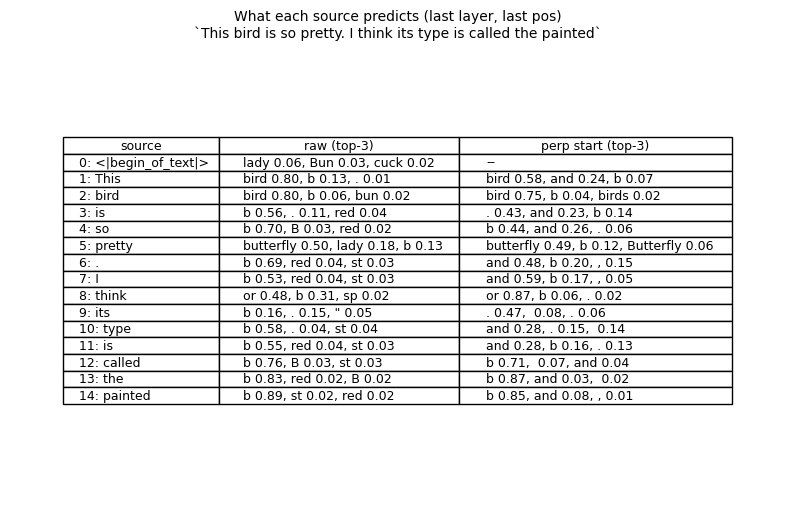

In [45]:
# New prompt -> fresh run (CACHE HIT if already cached, else a remote run).
PROMPT2 = "This bird is so pretty. I think its type is called the painted"
run2 = api_cache.get_full_run_results(MODEL, PROMPT2)
tokens2 = calculator.calc_tokens(PROMPT2)
LAST_POS2 = run2.dimentions.prompt_len - 1
N_LAYERS2 = run2.dimentions.layers

# Per-source contributions at the last layer/last position. Source 0 = start-of-context (BOS).
contributions2 = run2.contributions[
    LLMResidualPosition(layer=N_LAYERS2 - 1, token_position=LAST_POS2, is_mlp=True)
]  # (S, d_model)

raw_per_source2 = [top_preds(contributions2[i]) for i in range(len(tokens2))]
# remove_proj / predictions_table are defined in the prompt-1 per-source cell above.
minus_sources2 = range(1, len(tokens2))
minus_per_source2 = {i: top_preds(remove_proj(contributions2[i], contributions2[0])) for i in minus_sources2}

predictions_table(tokens2, raw_per_source2, minus_per_source2,
                  f"What each source predicts (last layer, last pos)\n`{PROMPT2}`")

CACHE HIT meta-llama/Llama-3.1-8B This building is so pretty. I think its type is called the painted 2026-06-17 22:42:04.139438
src  0  '<|begin_of_text|>'
          raw      : ' lady' 0.341, ' ladies' 0.177, ' Lady' 0.021, ' clap' 0.013, ' brick' 0.011
src  1               'This'
          raw      : ' building' 0.469, ' brick' 0.071, ' facade' 0.028, ' and' 0.023, ' fac' 0.018
          perp start: ' and' 0.708, ',' 0.104, '\n' 0.019, '-' 0.015, ' building' 0.013
src  2          ' building'
          raw      : ' building' 0.673, ' brick' 0.142, ' facade' 0.028, ' architecture' 0.026, ' fac' 0.022
          perp start: ' building' 0.452, ' fac' 0.093, ' and' 0.044, ' brick' 0.039, ' architecture' 0.029
src  3                ' is'
          raw      : '.' 0.213, ' lady' 0.056, '.\n' 0.039, ' one' 0.038, ' building' 0.032
          perp start: '.' 0.383, ' and' 0.236, '.\n' 0.077, ' one' 0.034, ' in' 0.017
src  4                ' so'
          raw      : ' pretty' 0.348, ' gorgeous' 0.

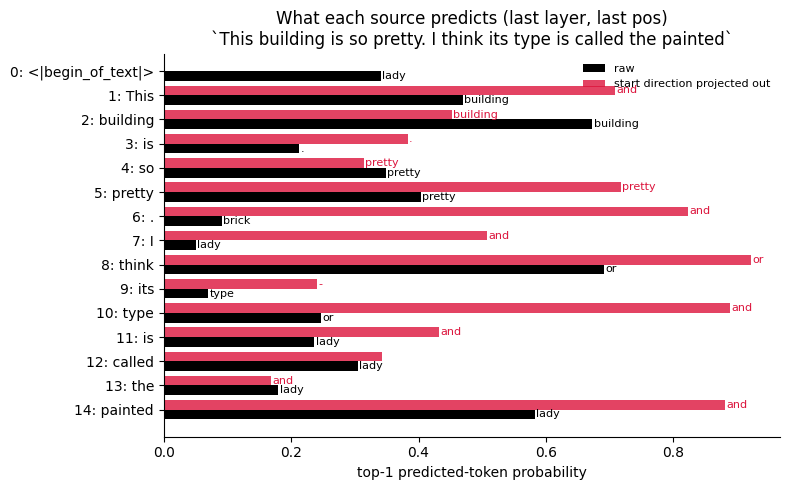

In [43]:
# New prompt -> fresh run (CACHE HIT if already cached, else a remote run).
PROMPT2 = "This building is so pretty. I think its type is called the painted"
run2 = api_cache.get_full_run_results(MODEL, PROMPT2)
tokens2 = calculator.calc_tokens(PROMPT2)
LAST_POS2 = run2.dimentions.prompt_len - 1
N_LAYERS2 = run2.dimentions.layers

# Per-source contributions at the last layer/last position. Source 0 = start-of-context (BOS).
contributions2 = run2.contributions[
    LLMResidualPosition(layer=N_LAYERS2 - 1, token_position=LAST_POS2, is_mlp=True)
]  # (S, d_model)

raw_per_source2 = [top_preds(contributions2[i]) for i in range(len(tokens2))]
# remove_proj (vector rejection) is defined in the prompt-1 per-source cell above.
minus_sources2 = range(1, len(tokens2))
minus_per_source2 = {i: top_preds(remove_proj(contributions2[i], contributions2[0])) for i in minus_sources2}

for i in range(len(tokens2)):
    print(f"src {i:>2} {tokens2[i]!r:>20}")
    print(f"          raw      : {fmt(raw_per_source2[i])}")
    if i in minus_per_source2:
        print(f"          perp start: {fmt(minus_per_source2[i])}")

# Pretty view: top-1 predicted token + its probability per source, raw vs. start-direction removed.
fig, ax = plt.subplots(figsize=(8, 5))
raw_top2 = [next(iter(p.items())) for p in raw_per_source2]
minus_top2 = {i: next(iter(p.items())) for i, p in minus_per_source2.items()}

ax.barh([i + 0.2 for i in range(len(tokens2))], [p for _, p in raw_top2],
        height=0.4, color="black", label="raw")
ax.barh([i - 0.2 for i in minus_top2], [p for _, p in minus_top2.values()],
        height=0.4, color="crimson", alpha=0.8, label="start direction projected out")
for i, (tok, p) in enumerate(raw_top2):
    ax.text(p + 0.002, i + 0.2, tok.strip(), va="center", fontsize=8)
for i, (tok, p) in minus_top2.items():
    ax.text(p + 0.002, i - 0.2, tok.strip(), va="center", fontsize=8, color="crimson")

ax.set_yticks(range(len(tokens2)))
ax.set_yticklabels([f"{i}: {tokens2[i].strip()}" for i in range(len(tokens2))])
ax.invert_yaxis()  # source 0 (BOS) at the top
ax.set_xlabel("top-1 predicted-token probability")
ax.set_title(f"What each source predicts (last layer, last pos)\n`{PROMPT2}`")
ax.legend(frameon=False, fontsize=8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

In [36]:
# Per-source view, RAW only (no -[0] subtraction), as a table.
import polars as pl

pl.Config.set_tbl_rows(100)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_hide_column_data_types(True)

raw_per_source2_only = [top_preds(contributions2[i]) for i in range(len(tokens2))]
K = max(len(p) for p in raw_per_source2_only)

table = {"token": [repr(t) for t in tokens2]}
for r in range(K):
    table[f"#{r + 1}"] = [
        f"{items[r][0].strip()!r} {items[r][1]:.3f}" if r < len(items := list(p.items())) else ""
        for p in raw_per_source2_only
    ]

pl.DataFrame(table)

token,#1,#2,#3,#4,#5
"""'<|begin_of_text|>'""","""'lady' 0.064""","""'Bun' 0.033""","""'cuck' 0.019""","""'Finch' 0.016""","""'king' 0.013"""
"""'This'""","""'bird' 0.796""","""'b' 0.130""","""'.' 0.008""","""'red' 0.007""","""'birds' 0.006"""
"""' bird'""","""'bird' 0.800""","""'b' 0.061""","""'bun' 0.021""","""'red' 0.009""","""'qu' 0.008"""
"""' is'""","""'b' 0.557""","""'.' 0.111""","""'red' 0.039""","""'.' 0.024""","""'B' 0.021"""
"""' so'""","""'b' 0.699""","""'B' 0.033""","""'red' 0.021""","""'.' 0.018""","""'and' 0.016"""
"""' pretty'""","""'butterfly' 0.500""","""'lady' 0.180""","""'b' 0.131""","""'bun' 0.021""","""'Butterfly' 0.021"""
"""'.'""","""'b' 0.689""","""'red' 0.037""","""'st' 0.028""","""'.' 0.020""","""'B' 0.017"""
"""' I'""","""'b' 0.534""","""'red' 0.039""","""'st' 0.033""","""'B' 0.026""","""'or' 0.023"""
"""' think'""","""'or' 0.480""","""'b' 0.310""","""'sp' 0.018""","""'red' 0.016""","""'st' 0.015"""
"""' its'""","""'b' 0.157""","""'.' 0.152""","""'""' 0.052""","""'red' 0.042""","""'.' 0.040"""


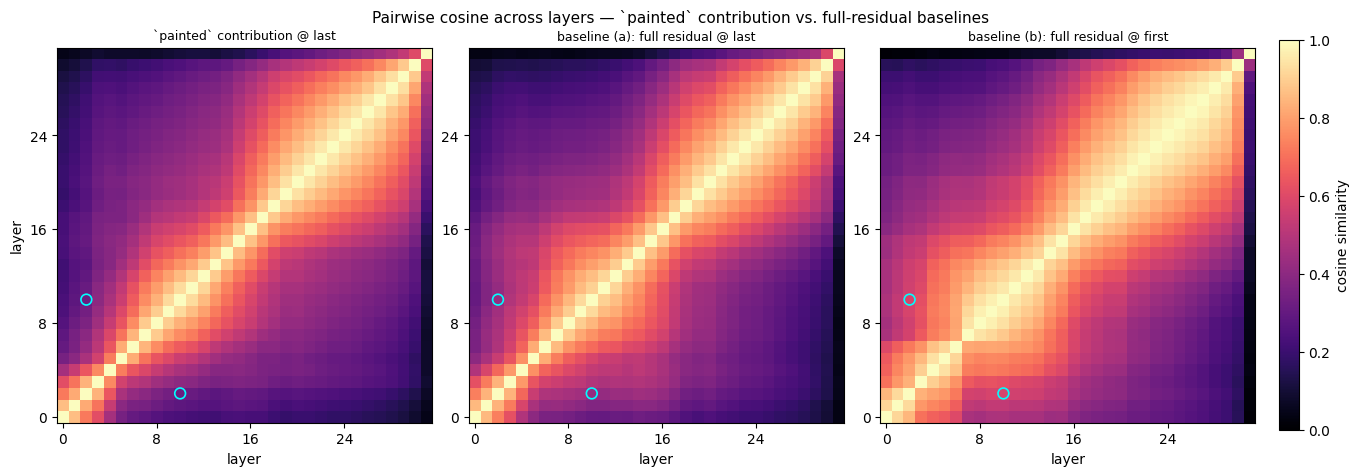

In [29]:
# Pairwise cosine heatmaps for the `painted` contribution on prompt 2, same style as the
# `hate` panels above: `painted` contribution @ last + the two full-residual baselines.
# (`painted` is now the last source token, so this is its self-contribution across layers.)
painted_sources = [i for i, t in enumerate(tokens2) if "painted" in t.lower()]
assert len(painted_sources) == 1, f"expected one 'painted' token, got {painted_sources}"
PAINTED_SOURCE = painted_sources[0]

# One vector per layer: contribution at the last position sourced from `painted`.
painted_vectors_per_layer = [
    run2.contributions[LLMResidualPosition(layer=l, token_position=LAST_POS2, is_mlp=True)][PAINTED_SOURCE].float()
    for l in range(N_LAYERS2)
]
# Full-residual baselines for prompt 2 (all sources summed), from run2.precise.
full_last_per_layer2 = [
    run2.precise[LLMResidualPosition(layer=l, token_position=LAST_POS2, is_mlp=True)].float()
    for l in range(N_LAYERS2)
]
full_first_per_layer2 = [
    run2.precise[LLMResidualPosition(layer=l, token_position=1, is_mlp=True)].float()
    for l in range(N_LAYERS2)
]

panels2 = [
    (pairwise_cosine_matrix(painted_vectors_per_layer), f"`{tokens2[PAINTED_SOURCE].strip()}` contribution @ last"),
    (pairwise_cosine_matrix(full_last_per_layer2), "baseline (a): full residual @ last"),
    (pairwise_cosine_matrix(full_first_per_layer2), "baseline (b): full residual @ first"),
]
ticks2 = range(0, N_LAYERS2, 8)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), constrained_layout=True)
for ax, (mat, title) in zip(axes, panels2):
    im = ax.imshow(mat.numpy(), origin="lower", cmap="magma", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("layer")
    ax.set_xticks(ticks2)
    ax.set_yticks(ticks2)
    ax.scatter([10, 2], [2, 10], facecolors="none", edgecolors="cyan", s=60, linewidths=1.2)  # L2 vs L10
axes[0].set_ylabel("layer")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="cosine similarity")
fig.suptitle(f"Pairwise cosine across layers — `{tokens2[PAINTED_SOURCE].strip()}` contribution vs. full-residual baselines", fontsize=11)
plt.show()

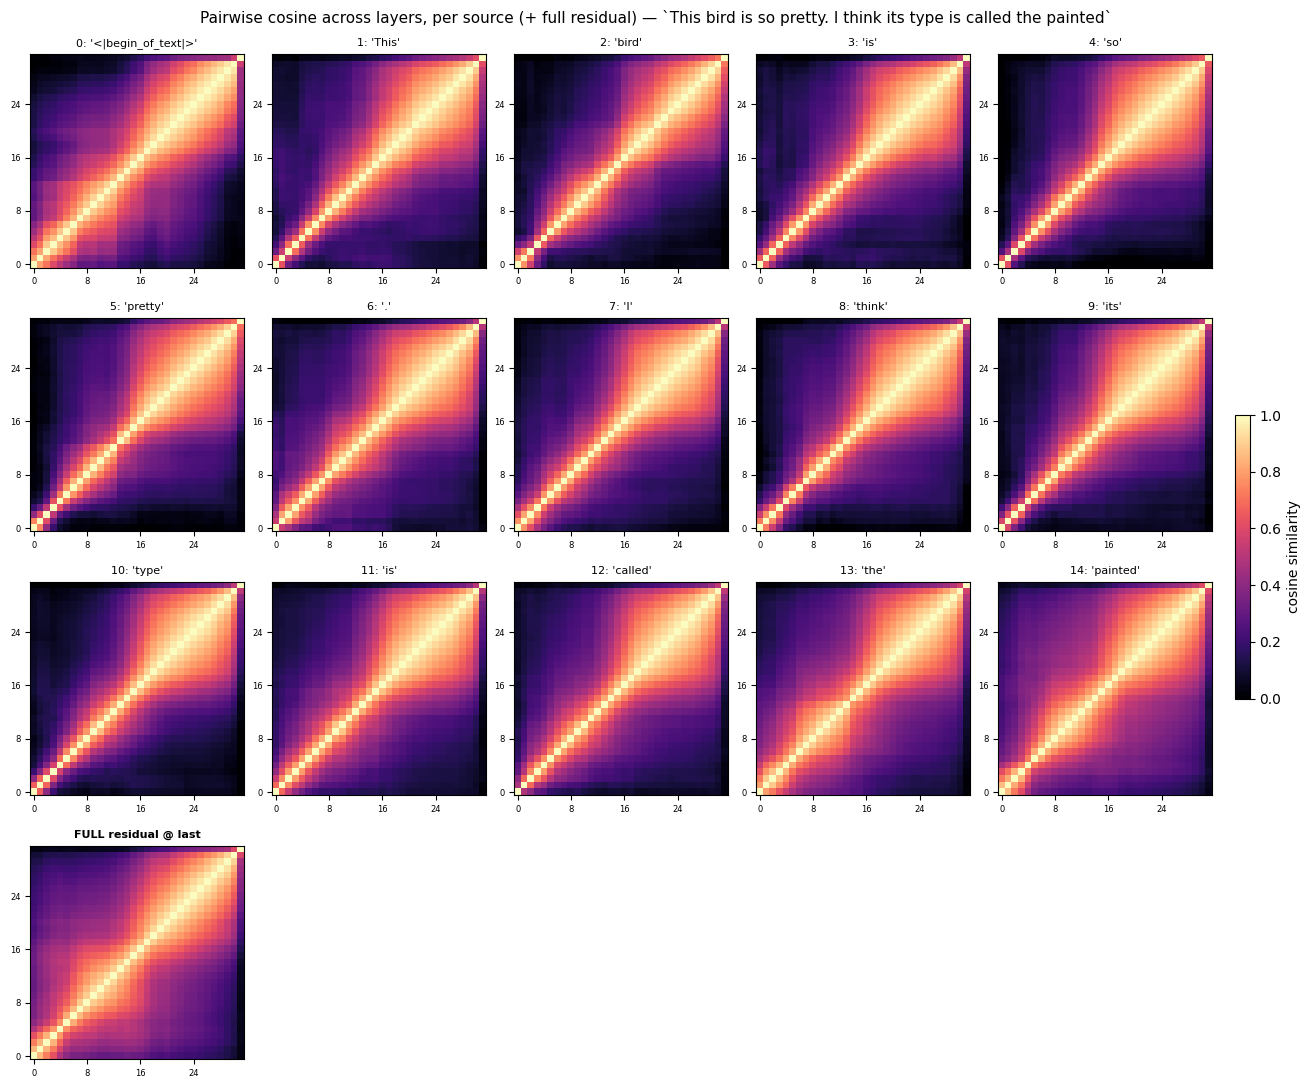

In [32]:
# Same pairwise-cosine heatmap, now one panel PER SOURCE token: how each source's
# contribution at the last position evolves (self-similarity) across all 32 layers.
# Plus one extra panel at the bottom: the FULL residual (sum of all sources) at the last pos.
import math

# (L, S, d): per-layer, per-source contributions at the last position.
C2 = torch.stack([
    run2.contributions[LLMResidualPosition(layer=l, token_position=LAST_POS2, is_mlp=True)].float()
    for l in range(N_LAYERS2)
])  # (L, S, d)
S = C2.shape[1]

# Full residual stream (all sources summed) at the last position, one vector per layer.
full_last_vectors2 = [
    run2.precise[LLMResidualPosition(layer=l, token_position=LAST_POS2, is_mlp=True)].float()
    for l in range(N_LAYERS2)
]

# Panels: every source, then the full residual as the final panel.
panel_mats = [pairwise_cosine_matrix([C2[l, s] for l in range(N_LAYERS2)]) for s in range(S)]
panel_titles = [f"{s}: {tokens2[s].strip()!r}" for s in range(S)]
panel_mats.append(pairwise_cosine_matrix(full_last_vectors2))
panel_titles.append("FULL residual @ last")

ncols = 5
nrows = math.ceil(len(panel_mats) / ncols)
ticks2 = range(0, N_LAYERS2, 8)

fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.7 * nrows), constrained_layout=True)
axes = axes.ravel()
for p, (mat, title) in enumerate(zip(panel_mats, panel_titles)):
    ax = axes[p]
    im = ax.imshow(mat.numpy(), origin="lower", cmap="magma", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=8, fontweight="bold" if title.startswith("FULL") else "normal")
    ax.set_xticks(ticks2)
    ax.set_yticks(ticks2)
    ax.tick_params(labelsize=6)
for p in range(len(panel_mats), len(axes)):  # hide any unused panels
    axes[p].axis("off")

fig.colorbar(im, ax=axes.tolist(), fraction=0.012, pad=0.02, label="cosine similarity")
fig.suptitle(f"Pairwise cosine across layers, per source (+ full residual) — `{PROMPT2}`", fontsize=11)
plt.show()